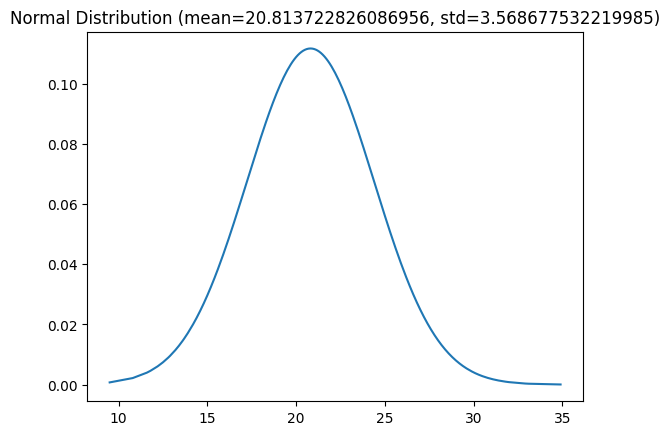

Probability is 0.12038563078530784


In [1]:
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
sys.path.append("/Users/gabriel/Desktop/Quant_Project/Quant-Summer-Project")

from data.fetcher import fetch_data
from data.cleaner import clean_data
from data.loader import add_event_column,filter_summer
from config.settings import HISTORICAL_START,HISTORICAL_END,DEFAULT_CITY
from scipy.stats import norm
from models.baseline import gaussian_probability


df_raw = fetch_data(HISTORICAL_START,HISTORICAL_END)


df_clean = clean_data(df_raw)


df_event = add_event_column(df_clean)


df_temp_summer = filter_summer(df_event)

df_temp_list = df_temp_summer["temperature_2m_max"].to_list()


df_sorted = sorted(df_temp_list)
P,my,sigma = gaussian_probability(df_sorted,25)

df_norm = norm.pdf(df_sorted,my,sigma)

plt.plot(df_sorted,df_norm)

plt.title(f'Normal Distribution (mean={my}, std={sigma})')
plt.show()
print(f"Probability is {P}")






We are using a baseline model, we started with a Gaussian to have a benchmark to compare models we will build in the future. If those models can't beat the Gaussian baseline, then they are not worth the complexity. The threshold is 25 Celsius and we are estimating the probability of the temperature being greater than that.

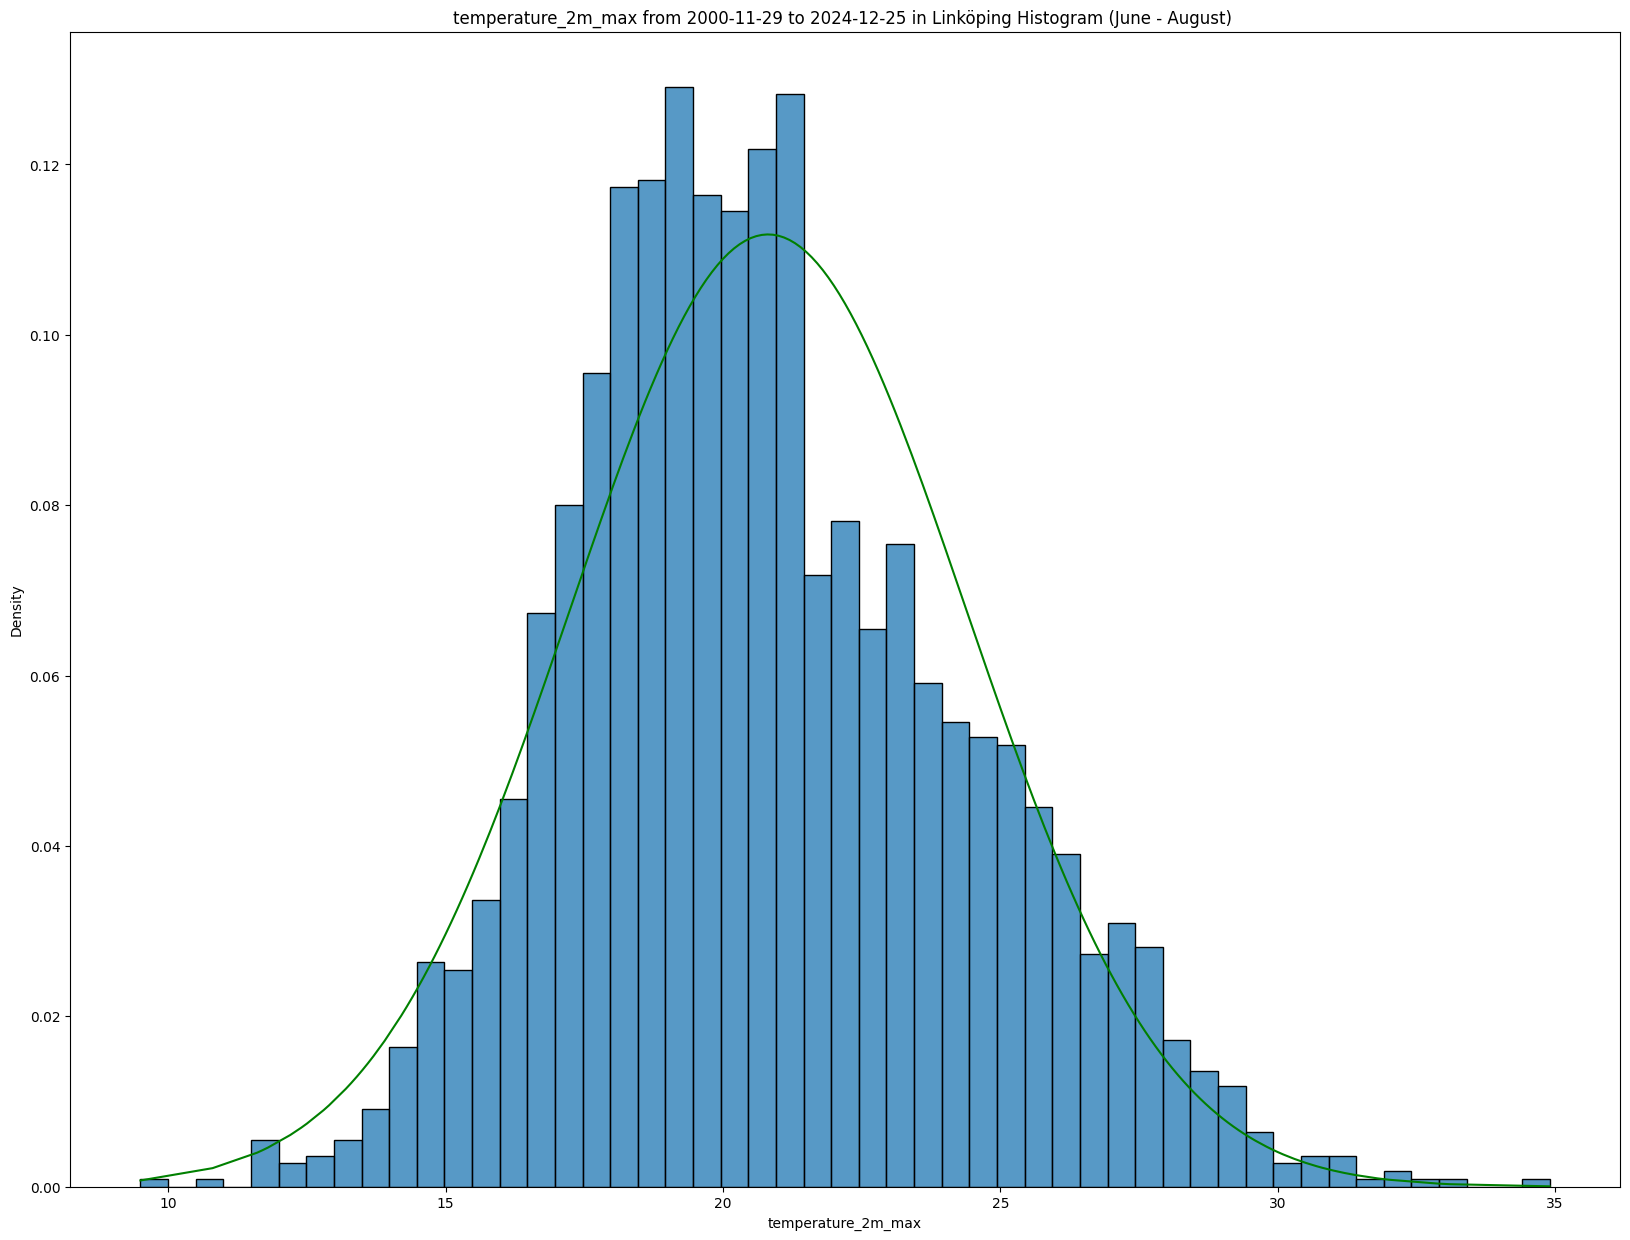

In [17]:
plt.figure(figsize =(20,15))
plt.title(f"temperature_2m_max from {HISTORICAL_START} to {HISTORICAL_END} in {DEFAULT_CITY} Histogram (June - August) ")
plt.xlabel("temperature_2m_max")
ax = sns.histplot( x= df_temp_list ,stat="density",binwidth=0.5)
x = df_sorted
y = df_norm
plt.plot(x,y,color = "green")
#plt.legend()
plt.show()


The normal distribution curve is fitting on the lower temperatures 10 - 17 Celsius, but is then skewed off. We can see that we have two peaks, one at 17 Celsius and one at 21 Celsius. This is kind of a bimodal distribution and could be because we have one colder month and one hotter month (June and August). At 25 Celsius it's actually aligned with the curve, so the curve might not be fully symmetric but at our threshold it's a better fit.